# Question 1: What demographic, socioeconomic, and extracurricular factors are most associated with student academic performance?

In [5]:
import pandas as pd
from statsmodels.stats.weightstats import ztest
import matplotlib.pyplot as plt

# load data
df1 = pd.read_csv("ResearchInformation3.csv")
df2 = pd.read_csv("student-mat.csv", sep=";")

# clean whitespace from Income
df1["Income"] = df1["Income"].str.strip()

# convert Income to 2 Groups
def income_to_binary(x):
    if "Below" in x:
        return "Low"
    else:
        return "High"

df1["Income_binary"] = df1["Income"].apply(income_to_binary)

# Z-TEST FUNCTION
def run_ztest(df, group_col, target_col):
    levels = df[group_col].unique()
    g1 = df[df[group_col] == levels[0]][target_col]
    g2 = df[df[group_col] == levels[1]][target_col]
    z, p = ztest(g1, g2)
    print(f"{group_col} Z-test: z = {z:.3f}, p = {p:.4f}")

# RUN Z-TESTS
run_ztest(df1, "Gender", "Overall")
run_ztest(df1, "Extra", "Overall")
run_ztest(df1, "Income_binary", "Overall")

Gender Z-test: z = -3.596, p = 0.0003
Extra Z-test: z = 7.320, p = 0.0000
Income_binary Z-test: z = 0.703, p = 0.4822


# Visualizations

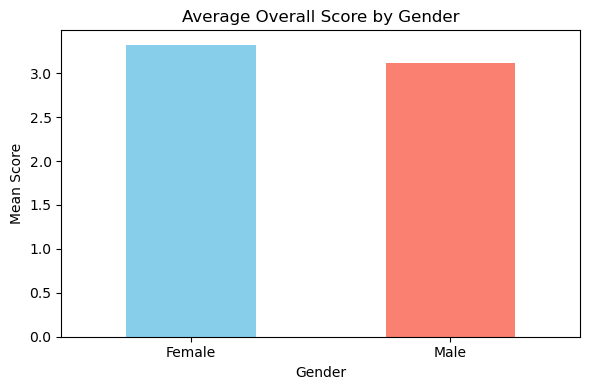

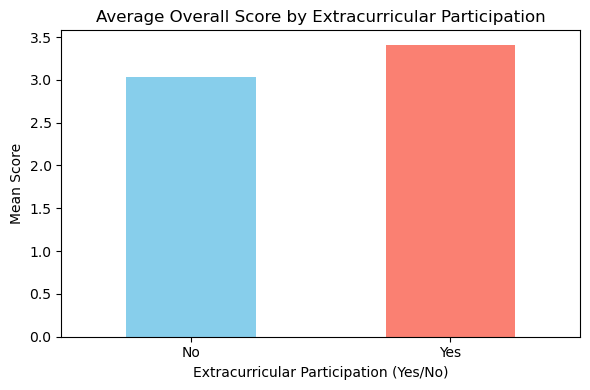

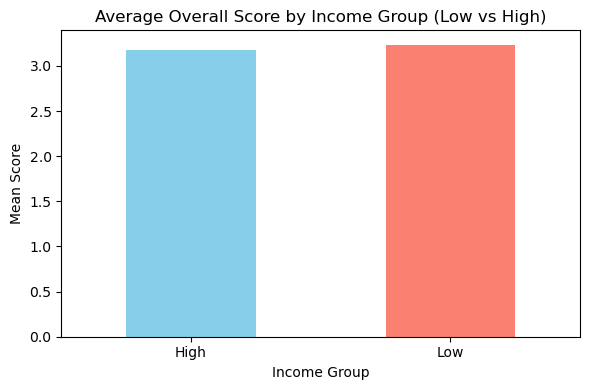

In [6]:
def plot_mean_bars(df, group_col, value_col, title, xlabel, ylabel="Mean Score"):
    means = df.groupby(group_col)[value_col].mean()
    means.plot(kind="bar", color=["skyblue", "salmon"], figsize=(6,4))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
# Gender vs Overall
plot_mean_bars(
    df1, 
    "Gender", 
    "Overall", 
    "Average Overall Score by Gender",
    "Gender"
)

# Extra vs Overall
plot_mean_bars(
    df1, 
    "Extra", 
    "Overall", 
    "Average Overall Score by Extracurricular Participation",
    "Extracurricular Participation (Yes/No)"
)

# Income_binary vs Overall
plot_mean_bars(
    df1,
    "Income_binary",
    "Overall",
    "Average Overall Score by Income Group (Low vs High)",
    "Income Group"
)

# Question 3: How do school-related factors—such as parent involvement, study time, attendance, and school support—affect student performance?

In [7]:
# convert Studytime to 2 Groups
df2["study_binary"] = df2["studytime"].apply(lambda x: "Low" if x <= 2 else "High")

# convert Absences to 2 Groups
cut = df2["absences"].median()
df2["abs_binary"] = df2["absences"].apply(lambda x: "Low" if x <= cut else "High")

# RUN Z-TESTS
run_ztest(df2, "study_binary", "G3")
run_ztest(df2, "abs_binary", "G3")
run_ztest(df2, "schoolsup", "G3")
run_ztest(df2, "famsup", "G3")

study_binary Z-test: z = -2.267, p = 0.0234
abs_binary Z-test: z = 1.524, p = 0.1276
schoolsup Z-test: z = -1.647, p = 0.0996
famsup Z-test: z = 0.777, p = 0.4372


# Visualization

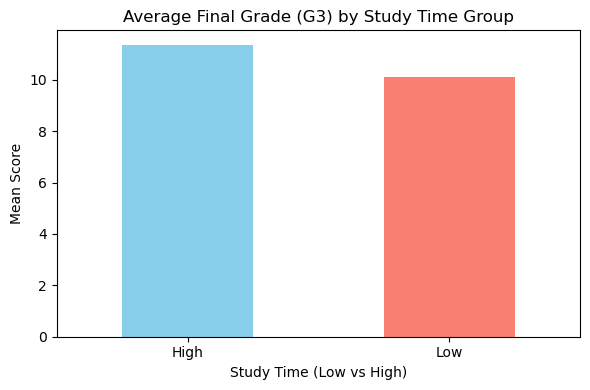

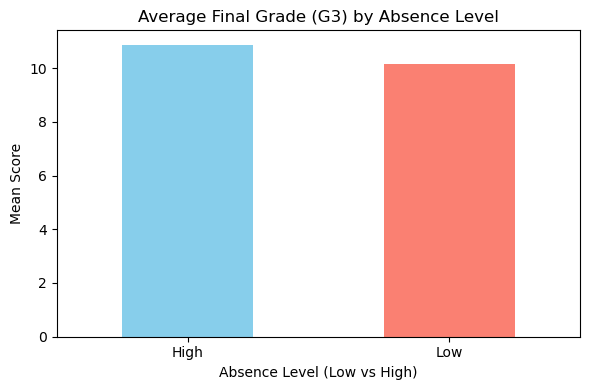

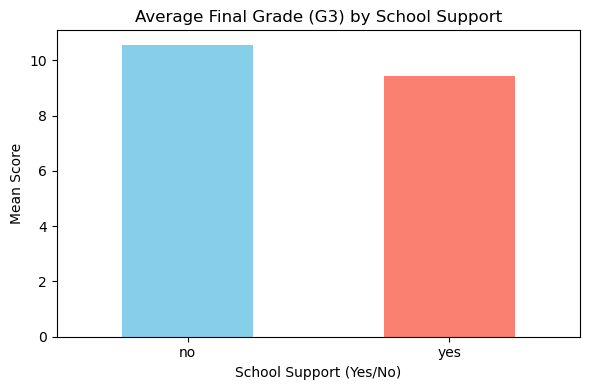

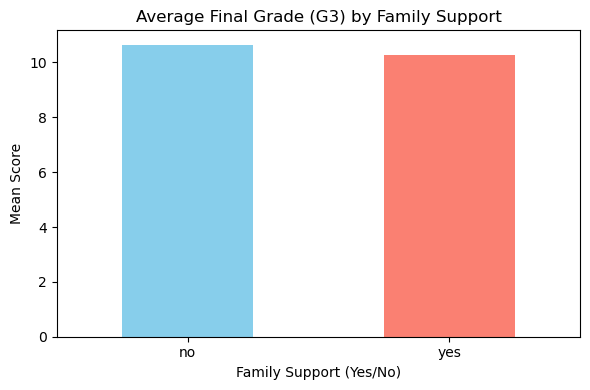

In [8]:
# Studytime (binary) vs G3
plot_mean_bars(
    df2,
    "study_binary",
    "G3",
    "Average Final Grade (G3) by Study Time Group",
    "Study Time (Low vs High)"
)

# Absences (binary) vs G3
plot_mean_bars(
    df2,
    "abs_binary",
    "G3",
    "Average Final Grade (G3) by Absence Level",
    "Absence Level (Low vs High)"
)

# School support vs G3
plot_mean_bars(
    df2,
    "schoolsup",
    "G3",
    "Average Final Grade (G3) by School Support",
    "School Support (Yes/No)"
)

# Family support vs G3
plot_mean_bars(
    df2,
    "famsup",
    "G3",
    "Average Final Grade (G3) by Family Support",
    "Family Support (Yes/No)"
)